## Математическая статистика для анализа больших данных

### Семинар 13

**Правила:**


* Выполненную работу нужно отправить [телеграм-боту](https://t.me/stats_bd_bot).
* Дедлайн указан в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно ноутбук в формате `ipynb`.
* Если вы прикрепляете фотографии к ноутбуку, убедитесь, что они "вшиты" туда, а не ссылаются на локальный путь
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Публикация решения может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm

import warnings

sns.set(palette='Set2')
warnings.filterwarnings('ignore')

%matplotlib inline

## Задача 1

Подбросив монету 250 раз, 140 раз была получена решка. Какова вероятность выпадения решки?

Постройте для данной задачи модель. В качестве априорного распределения для параметра вероятности используйте бета распределение с параметрами $\alpha=1$ и $\beta=1$.

**Описание:**

$$X | \theta \sim Bern(\theta), \ \theta \sim B(1, 1)$$

Создайте описанную модель с помощью PyMC. Просемплируйте в ней искомый параметр:

In [2]:
n = 250
s = 140

with pm.Model() as model:
    # априорные распределения средних
    theta = pm.Beta('theta', 1, 1)

    # распределение данных
    X = pm.Bernoulli(
        'X', p=theta, observed=[1]*s + [0]*(n-s)
    )

    trace = pm.sample(2000, tune=500)

Output()

Output()

Из полученного семпла постройте гистограмму и оцените значение вероятности:

In [3]:
theta_samples = trace.posterior.theta.to_numpy().ravel()

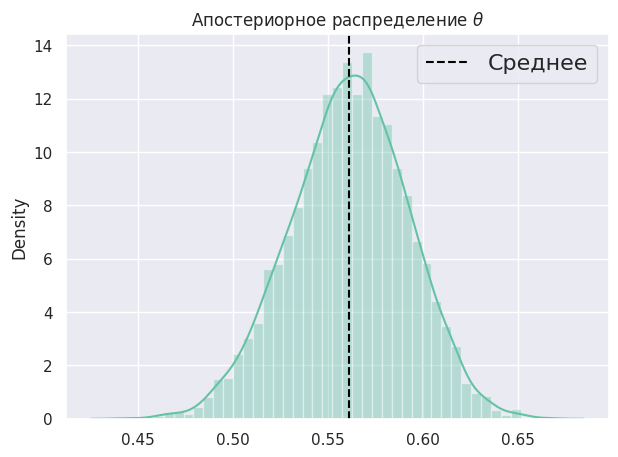

In [4]:
plt.figure(figsize=(7, 5))
plt.title(r'Апостериорное распределение $\theta$')
sns.distplot(theta_samples)
plt.axvline(theta_samples.mean(), ls='--', color='black', label=r'Среднее')
plt.legend(fontsize=16)
plt.show()

## Задача 2

Будем считать, что количество забитых голов некоторой команды в футбольном матче имеет пуассоновское распределение с параметром $\lambda$. На этот параметр задано априорное распределение $\Gamma(1.4, 1)$.

За первый матч команде удалось забить 4 гола. С помощью PyMC постройте модель процесса и оцените параметр $\lambda$

Output()

Output()

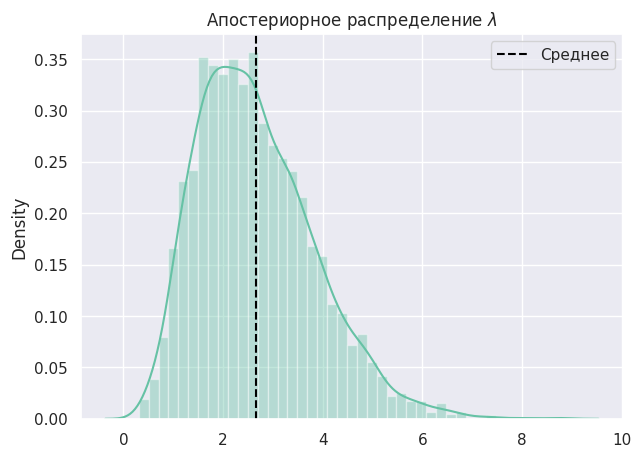

In [5]:
with pm.Model() as model_poisson:
    lam = pm.Gamma('lam', alpha=1.4, beta=1)  # beta - rate
    X_goals = pm.Poisson('X_goals', mu=lam, observed=4)
    trace_poisson = pm.sample(2000, tune=500)

lam_samples = trace_poisson.posterior.lam.to_numpy().ravel()

plt.figure(figsize=(7,5))
sns.distplot(lam_samples)
plt.title(r'Апостериорное распределение $\lambda$')
plt.axvline(lam_samples.mean(), ls='--', color='black', label='Среднее')
plt.legend()
plt.show()


Оцените вероятность того, что в следующем матче голов будет не меньше:

In [6]:
# P(X≥3|λ) = 1 - P(X<3) = 1 - (P(X=0)+P(X=1)+P(X=2))
# Рассчитаем эмпирически, усредняя по λ из апостериора:
prob_ge_3 = []
for lam_val in lam_samples:
    p = 1 - (sps.poisson.cdf(2, lam_val))
    prob_ge_3.append(p)
print("P(X≥3|Data) ~", np.mean(prob_ge_3))


P(X≥3|Data) ~ 0.46379222013257754


## Задача 3

Хотим посчитать количество медведей в лесу. Сначала поймали `k=23`, поставили метку и отпустили. Через какое-то время поймали `n=19` медведей, из которых с меткой оказалось `x=4`. Оцените апостериорное распределение параметра &mdash; числа медведей.

В качестве априорного используйте равномерное распределение на отрезке от 50 до 500

*Замечание:* https://en.wikipedia.org/wiki/Hypergeometric_distribution

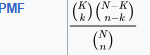

Output()

Output()

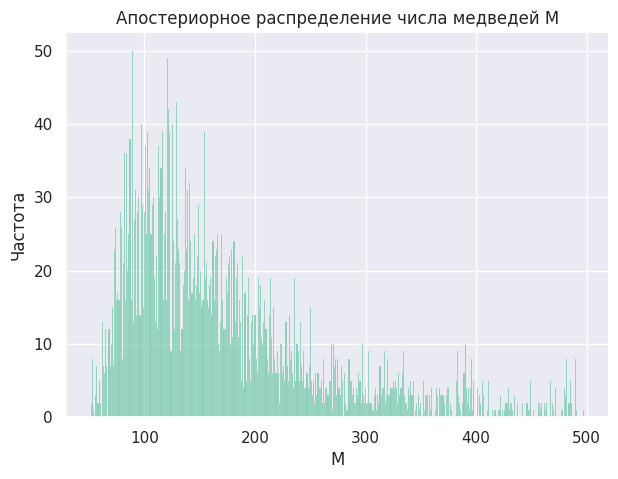

In [14]:
k = 23
n = 19
x = 4

with pm.Model() as model_bears:
    # M - общее число медведей (неизвестное)
    M = pm.DiscreteUniform('M', lower=50, upper=500)

    X_obs = pm.HyperGeometric('X_obs', N=M, k=k, n=n, observed=x)

    trace_bears = pm.sample(2000, tune=500)

M_samples = trace_bears.posterior.M.values.flatten()

plt.figure(figsize=(7,5))
sns.histplot(M_samples, discrete=True, kde=False)
plt.title("Апостериорное распределение числа медведей M")
plt.xlabel("M")
plt.ylabel("Частота")
plt.show()


## Задача 4

В некотором врачебном эксперименте пациенту случайно выдается лекарство или плацебо. После этого он проходит тест, успешность которого варьируется в баллах от 0 до 100. Необходимо понять успешность данного лекарства.

Сначала считаем данные:

In [26]:
df = pd.read_csv('drp_scores.csv', skiprows=21, delimiter='\t')
df.head()

,Treatment,Response
0,Treated,24
1,Treated,43
2,Treated,58
3,Treated,71
4,Treated,43


Разбейте данные на контрольную и тестовую группы:

In [30]:
control = df[df['Treatment']=='Control']['Response'].values
treated = df[df['Treatment']=='Treated']['Response'].values

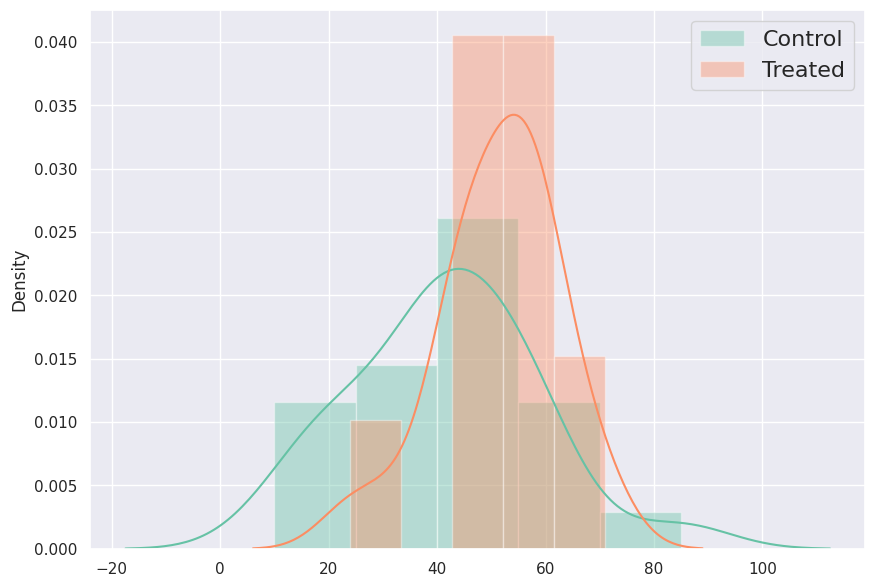

In [31]:
plt.figure(figsize=(10, 7))
sns.distplot(control, label='Control')
sns.distplot(treated, label='Treated')
plt.legend(fontsize=16)
plt.show()

Будем считать, что данные тестовой группы описываются нормальным распределением. В качестве априорного распределения на параметры смещения и дисперсии используются равномерные распределения. Постройте такую модель в PyMC:

In [32]:
with pm.Model() as model_treated:
    mu = pm.Uniform('mu', lower=0, upper=100)
    sigma = pm.Uniform('sigma', lower=0, upper=50)
    X_treated = pm.Normal('X_treated', mu=mu, sigma=sigma, observed=treated)

    trace_treated = pm.sample(2000, tune=500)

Output()

Output()

Рассмотрите предиктивное распределение результатов теста для тестовой группы. Сравните его с распределением контрольной группы. Что можно сказать о лечении?

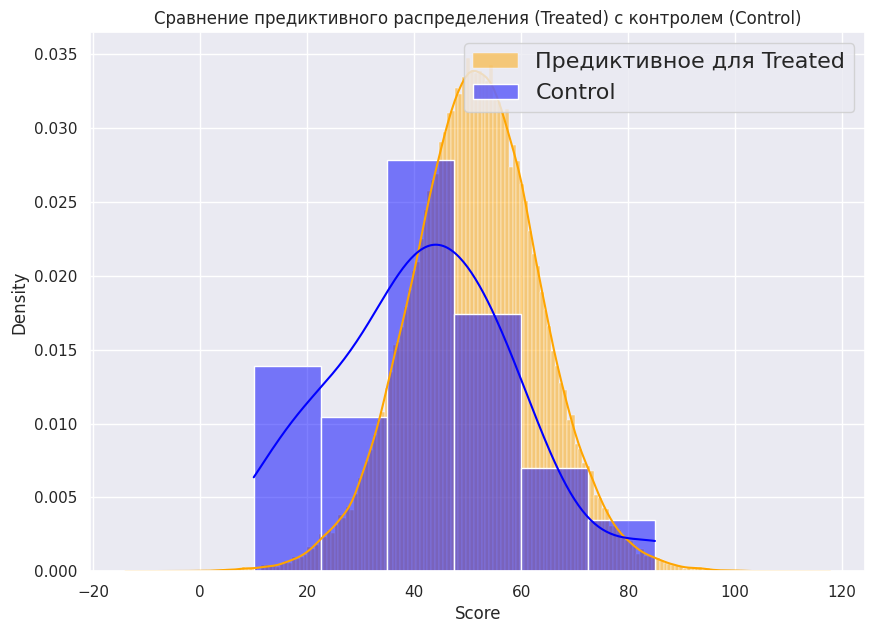

In [34]:
plt.figure(figsize=(10,7))

# Предиктивное для Treated
sns.histplot(X_treated_pred.ravel(), color='orange', label='Предиктивное для Treated', kde=True, stat='density', alpha=0.5)
# Контрольная группа
sns.histplot(control, color='blue', label='Control', kde=True, stat='density', alpha=0.5)

plt.legend(fontsize=16)
plt.title('Сравнение предиктивного распределения (Treated) с контролем (Control)')
plt.xlabel('Score')
plt.ylabel('Density')
plt.show()


**Вывод**: Судя по полученному графику, предиктивное распределение для группы, получившей лечение (Treated), сосредоточено в области более высоких значений по сравнению с контрольной группой (Control). Это говорит о том, что при данном лекарстве ожидаемый результат теста смещается в сторону большего числа баллов. Другими словами, модель предсказывает, что пациенты, получившие лечение, с большей вероятностью продемонстрируют более высокий результат, чем те, кто получил плацебо. Таким образом, можно сделать вывод о потенциальной эффективности данного лекарства в улучшении показателей теста.